In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import joblib

from gplearn.genetic import SymbolicClassifier

import torch
import torch.nn as nn

sns.set_style("ticks")

In [2]:
# Data
from src.debbirth.data.schema import DatasetSpec
from src.debbirth.data.load import load_data_gp, load_data_pytorch
# GP
from src.debbirth.models.gp.algorithm import DEBBirthSymbolicClassifier
from src.debbirth.models.gp.train import load_gp_run
# NN
from src.debbirth.models.nn.train import load_trained_nn
# Evaluate
from src.debbirth.evaluate.metrics import BinaryMetrics
from src.debbirth.evaluate.compare import compile_metrics, results_df_to_latex

# Setup

In [3]:
save_figure_dir = Path(r"C:\Users\diogo\OneDrive - Universidade de Lisboa\Conferences\2026\World Conference on Computational Intelligence\figures")

# Load models

In [4]:
best_models_path = Path().cwd().parent / "results" / "models"

## Load Genetic Programming model

In [5]:
gp_model_path = best_models_path / "DEBBirthGP"
loaded_gp = load_gp_run(gp_model_path)

In [6]:
gp = loaded_gp["model"]
gp_train_cfg = loaded_gp["train_cfg"]

## Load Neural Network model

In [7]:
nn_model_path = best_models_path / "DEBBirthNet"
loaded_nn = load_trained_nn(nn_model_path)

In [8]:
nn = loaded_nn["model"]
scaler = loaded_nn["scaler"]
nn_train_cfg = loaded_nn["train_cfg"]

In [9]:
nn_train_cfg

TrainDEBBirthNetConfig(data_spec=DatasetSpec(feature_set='dimensionless', target_col='reached_birth'), data_splits='train_val_test', data_dir=WindowsPath('C:/Users/diogo/OneDrive - Universidade de Lisboa/Terraprima/Code/DEB Constraint Prediction/deb-birth-prediction/data/processed'), epochs=100, batch_size=64, lr=0.0001, weight_decay=0.001, net_config=DEBBirthNetConfig(input_dim=4, hidden_dims=[32, 32, 32], dropout=0.2, threshold=0.5), scaling_type='log_standardize', use_pos_weight=True, pos_weight=0.11595930904150009, seed=42, num_workers=4, device='cpu', outdir=WindowsPath('results/runs/2026-01-27T19-54-14_DEBBirthNet'))

# Load data


In [10]:
data_spec = DatasetSpec(feature_set="dimensionless")

## Genetic Programing

In [11]:
features, targets = load_data_gp(gp_train_cfg)

## Neural Network

In [12]:
scaled_input_data, targets_nn, dataloaders, datasets, scaler = load_data_pytorch(config=nn_train_cfg, scaler=scaler)


# Get test set predictions

## Genetic Programing

In [13]:
gp_test_metrics = BinaryMetrics.load_json(gp_model_path / "metrics" / "test_metrics.json")
gp_test_metrics

BinaryMetrics(accuracy=0.9602380308358128, precision_pos=0.9967576613324965, recall_pos=0.9587525150905433, f1_pos=0.977385775088457, precision_neg=0.7320261437908496, recall_neg=0.9730668983492615, f1_neg=0.835509138381201, precision_macro=0.8643919025616731, recall_macro=0.9659097067199024, f1_macro=0.9064474567348291, auroc=0.9808041996549234, avg_precision=0.9971039703758546, auroc_macro=0.9808041996549235, avg_precision_macro=0.9462477030839747, tp=9530, fp=31, tn=1120, fn=410)

In [14]:
gp_test_set_probs = gp.predict_proba(features["test"])
gp_test_set_preds = np.argmax(gp_test_set_probs, axis=1)

## Neural Network

In [15]:
nn_test_metrics = BinaryMetrics.load_json(nn_model_path / "metrics" / "test_metrics.json")
nn_test_metrics

BinaryMetrics(accuracy=0.9854837255432333, precision_pos=0.9888033589923023, recall_pos=0.9950704225352113, f1_pos=0.991926991926992, precision_neg=0.9549632352941176, recall_neg=0.9026933101650738, f1_neg=0.9280928986154533, precision_macro=0.97188329714321, recall_macro=0.9488818663501426, f1_macro=0.9600099452712226, auroc=0.998253115565679, avg_precision=0.99979789145776, auroc_macro=0.9982531155656791, avg_precision_macro=0.9930146644007747, tp=9891, fp=112, tn=1039, fn=49)

In [16]:
nn_test_set_probs = nn.predict_proba(scaled_input_data["test"])
nn_test_set_preds = torch.round(nn_test_set_probs)

# Test set comparison

## Metrics table

In [17]:
results_df = compile_metrics(metrics_dict={
    "GP": gp_test_metrics,
    "NN": nn_test_metrics,
})

In [18]:
latex_table_str = results_df_to_latex(results_df,
                                      columns=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro',],
                                      )
print(latex_table_str)

\begin{tabular}{lrrrr}
\toprule
 & Accuracy & Precision & Recall & F1 \\
\midrule
GP & 0.9602 & 0.8644 & 0.9659 & 0.9064 \\
NN & 0.9855 & 0.9719 & 0.9489 & 0.9600 \\
\bottomrule
\end{tabular}


In [19]:
# Save results table
results_path = Path().cwd().parent / "results" / "tables"

## Precision recall curve

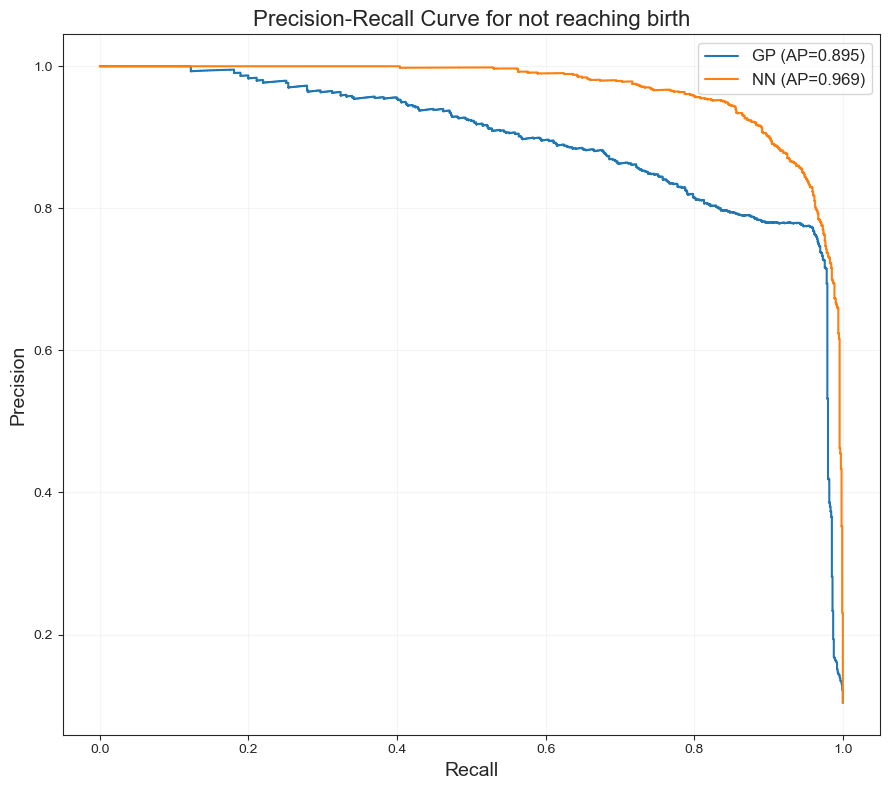

In [20]:
# Precision-Recall curve (positive class = y == 0), compare GP vs NN
from sklearn.metrics import precision_recall_curve, average_precision_score

# True labels (ensure numpy array)
y_test = targets["test"]
if isinstance(y_test, torch.Tensor):
    y_test = y_test.cpu().numpy()
y_test = np.asarray(y_test)

# GP: ensure we have probability for class 0
gp_probs = np.asarray(gp_test_set_probs)
if gp_probs.ndim == 2 and gp_probs.shape[1] >= 1:
    gp_prob0 = gp_probs[:, 0]
else:
    # if single-column probs assume they represent class 1, so invert
    gp_prob0 = 1.0 - gp_probs.squeeze()

# NN: convert to numpy and obtain prob for class 0
if isinstance(nn_test_set_probs, torch.Tensor):
    nn_p = nn_test_set_probs.detach().cpu().numpy()
else:
    nn_p = np.asarray(nn_test_set_probs)

# nn_p may be shape (n,1) or (n,) or (n,2)
if nn_p.ndim == 2:
    if nn_p.shape[1] == 1:
        nn_prob1 = nn_p.squeeze()
    else:
        # assume column 1 is prob of class 1
        nn_prob1 = nn_p[:, 1]
else:
    nn_prob1 = nn_p.squeeze()

nn_prob0 = 1.0 - nn_prob1

# Construct binary labels where positive = class 0
y_pos0 = (y_test == 0).astype(int)

# Compute precision-recall curves and average precision
gp_prec, gp_rec, _ = precision_recall_curve(y_pos0, gp_prob0)
nn_prec, nn_rec, _ = precision_recall_curve(y_pos0, nn_prob0)

gp_ap = average_precision_score(y_pos0, gp_prob0)
nn_ap = average_precision_score(y_pos0, nn_prob0)

# Plot using explicit Figure and Axes (use ax only, avoid plt.* plotting calls)
fig, ax = plt.subplots(figsize=(9, 8))
ax.step(gp_rec, gp_prec, where="post", label=f"GP (AP={gp_ap:.3f})")
ax.step(nn_rec, nn_prec, where="post", label=f"NN (AP={nn_ap:.3f})")
ax.set_xlabel("Recall", fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision-Recall Curve for not reaching birth", fontsize=16)
ax.legend(loc="best", fontsize=12)
ax.grid(alpha=0.2)
fig.tight_layout()


In [21]:
# Save precision recall curve in .png, .pdf, .svg formats
for ext in ["png", "pdf", "svg"]:
    save_path = save_figure_dir / f"precision_recall_curve_test_set.{ext}"
    fig.savefig(save_path, dpi=300)